# Activation Patching: Causal Tracing Through a Real Transformer

**Notebook 5 of the series.** Notebook 4 computed gradient-based and
occlusion-based attribution — real measurements, but each with a real
limitation: gradients are local, linear approximations, and occlusion tests
only one specific substitution in isolation. This notebook does something
structurally different: it directly **intervenes** on the model's internal
computation while it is running, and measures the causal effect of that
intervention on the output. This general technique is often called
**activation patching** or **causal tracing** in interpretability research,
and has been used (on other models and prompts) to help locate where and
when a language model causally relies on specific information during a
prediction.

Still out of scope: probing classifiers, circuit-level analysis of
individual attention heads, and fine-tuning. Those are further steps beyond
what this notebook covers.

## Learning objectives

1. What is activation patching, and how does it differ structurally from
   the gradient- and occlusion-based methods in notebook 4?
2. What is a "clean" run versus a "corrupted" run, and why corrupt at the
   embedding level with noise rather than substitute different words?
3. What does "patching" a layer's output at one token position actually do,
   mechanically, inside a real forward pass?
4. What does a real position-by-layer "recovery" heatmap show for our
   oilfield prompt, and what pattern does it reveal?
5. Why is this method more directly causal than gradients or occlusion —
   and what does it still *not* establish?
6. Does this notebook's result agree with notebook 3's attention weights and
   notebook 4's occlusion scores for the same prompt and target token?


## 1. What problem are we investigating?

Gradients and occlusion (notebook 4) each approximate or test one small
piece of the model's behavior. Activation patching instead runs the actual
network twice and forces one internal value to be swapped between the two
runs — a genuine intervention on the real computation, not an approximation
of it:

1. Run the model on the real ("clean") prompt, and **save** ("cache") the
   internal residual-stream output of every transformer layer, at every
   token position.
2. Run the model again on a **corrupted** version of the same prompt (same
   length, same positions — we corrupt by adding noise to a few token
   embeddings, not by substituting different words) and observe how much
   the prediction degrades.
3. For one specific (layer, position) at a time, **patch**: run the
   corrupted prompt again, but force that one layer's output at that one
   position to be the *clean* cached value instead of whatever the
   corrupted computation produced. Measure how much of the original,
   clean prediction gets restored.

Repeating step 3 across every layer and every position produces a 2D map of
where, in the network's depth and across the sequence, the information the
clean run relied on is causally recoverable.


## Installation (run once)

Same dependencies as the rest of the series. If already installed, skip
this cell.


In [1]:
# Run this once. After the packages are installed you can leave this commented out.
# %pip install torch transformers accelerate pandas matplotlib numpy
print("If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.")


If an import in the next cell fails, uncomment and run the pip install line above, then re-run this notebook.


## 2. Load the real language model

This notebook uses the same default setup as notebooks 1–2 (no special
`attn_implementation` or forced `float32` is required — verified while
building this notebook: patched forward passes produced no `NaN` in the
default float16-on-accelerated-hardware configuration).


In [2]:
import random
import platform
import sys
import time

import numpy as np
import pandas as pd
import torch
import transformers
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PRIMARY_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
FALLBACK_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"  # used only if the primary model fails to load

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

DTYPE = torch.float16 if DEVICE in ("mps", "cuda") else torch.float32

print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Selected device:      {DEVICE}")
print(f"Selected dtype:       {DTYPE}")


Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Selected device:      mps
Selected dtype:       torch.float16


In [3]:
def load_model(model_name: str = PRIMARY_MODEL_NAME):
    '''Load a causal language model and its tokenizer onto the selected device.

    Falls back to FALLBACK_MODEL_NAME if the primary model cannot be loaded,
    and always reports which model actually ended up running.
    '''
    try:
        tok = AutoTokenizer.from_pretrained(model_name)
        mdl = AutoModelForCausalLM.from_pretrained(model_name, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, model_name
    except Exception as exc:  # noqa: BLE001 - report and fall back, don't crash the notebook
        print(f"Could not load '{model_name}' ({exc}). Falling back to '{FALLBACK_MODEL_NAME}'.")
        tok = AutoTokenizer.from_pretrained(FALLBACK_MODEL_NAME)
        mdl = AutoModelForCausalLM.from_pretrained(FALLBACK_MODEL_NAME, dtype=DTYPE)
        mdl.to(DEVICE)
        mdl.eval()
        return tok, mdl, FALLBACK_MODEL_NAME


tokenizer, model, MODEL_NAME = load_model()
embedding_layer = model.get_input_embeddings()
NUM_LAYERS = model.config.num_hidden_layers
print(f"\nModel actually loaded and used in this notebook: {MODEL_NAME}")
print(f"Vocabulary size: {model.config.vocab_size:,} tokens, transformer layers: {NUM_LAYERS}")


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]


Model actually loaded and used in this notebook: Qwen/Qwen2.5-1.5B-Instruct
Vocabulary size: 151,936 tokens, transformer layers: 28


## 3. Reference prompt and target token

The same primary sentence used throughout this series. As in notebook 4, we
attribute the log-probability of the model's own top-predicted next token.


In [4]:
PROMPT = "The crew pulled out of hole with the worn PDC bit and prepared to run a new"

encoded = tokenizer(PROMPT, return_tensors="pt").to(DEVICE)
input_ids = encoded["input_ids"]
attention_mask = encoded["attention_mask"]
decoded_tokens = [tokenizer.decode([tid]) for tid in input_ids[0]]
position_labels = [repr(t) for t in decoded_tokens]
SEQ_LEN = input_ids.shape[1]

with torch.no_grad():
    clean_embeds = embedding_layer(input_ids)
    clean_logits = model(inputs_embeds=clean_embeds, attention_mask=attention_mask).logits[0, -1, :]

TARGET_ID = int(torch.argmax(clean_logits).item())
TARGET_TEXT = tokenizer.decode([TARGET_ID])

token_table = pd.DataFrame({"position": range(SEQ_LEN), "token_id": input_ids[0].tolist(), "decoded_token_repr": position_labels})
print(f"Prompt: {PROMPT!r}")
print(f"Target token (model's own top prediction): {TARGET_TEXT!r} (id {TARGET_ID})")
token_table


Prompt: 'The crew pulled out of hole with the worn PDC bit and prepared to run a new'
Target token (model's own top prediction): ' bit' (id 2699)


,position,token_id,decoded_token_repr
0,0,785,'The'
1,1,13627,' crew'
2,2,13238,' pulled'
3,3,700,' out'
4,4,315,' of'
5,5,14178,' hole'
6,6,448,' with'
7,7,279,' the'
8,8,23704,' worn'
9,9,393,' P'


## 4. Running the clean prompt and caching every layer's output

We register a **forward hook** on each of the model's 28 transformer
layers. A hook is a function PyTorch calls automatically every time that
layer finishes computing — we use it here just to *read and store* each
layer's output (the residual stream) at every token position, without
changing anything yet.


In [5]:
def cache_layer_outputs(embeds: torch.Tensor, attn_mask: torch.Tensor):
    '''Run a forward pass and return (logits, cache) where cache[i] is layer i's real output hidden states.'''
    cache = {}

    def make_hook(layer_index):
        def hook(module, inputs, output):
            hidden_states = output[0] if isinstance(output, tuple) else output
            cache[layer_index] = hidden_states.detach().clone()
        return hook

    handles = [model.model.layers[i].register_forward_hook(make_hook(i)) for i in range(NUM_LAYERS)]
    try:
        with torch.no_grad():
            out = model(inputs_embeds=embeds, attention_mask=attn_mask)
    finally:
        for h in handles:
            h.remove()
    return out.logits[0, -1, :], cache


clean_logits, clean_cache = cache_layer_outputs(clean_embeds, attention_mask)
clean_logprob = torch.log_softmax(clean_logits.float(), dim=-1)[TARGET_ID].item()

print(f"Cached {len(clean_cache)} layers, each shaped {tuple(clean_cache[0].shape)} (batch, position, hidden)")
print(f"Clean log P({TARGET_TEXT!r}) = {clean_logprob:.4f}")


Cached 28 layers, each shaped (1, 18, 1536) (batch, position, hidden)
Clean log P(' bit') = -1.0929


## 5. Corrupting the prompt

We corrupt the tokens that spell out "PDC bit" — positions 9, 10, and 11
(`' P'`, `'DC'`, `' bit'`) — by adding random Gaussian noise directly to
their embedding vectors, scaled to 3x the real standard deviation of the
model's own embedding matrix. This keeps the sequence length and every
other token identical to the clean prompt, so position-by-position
comparisons between the clean and corrupted runs stay meaningful — unlike
substituting a different word, which would shift token alignment.


In [6]:
CORRUPT_POSITIONS = [9, 10, 11]  # ' P', 'DC', ' bit'
print("Positions being corrupted:", [(i, position_labels[i]) for i in CORRUPT_POSITIONS])

embedding_std = embedding_layer.weight.float().std().item()
noise_scale = 3.0 * embedding_std
print(f"Embedding matrix std: {embedding_std:.5f}, noise scale used: {noise_scale:.5f}")

generator = torch.Generator(device="cpu").manual_seed(SEED)
noise = torch.randn(len(CORRUPT_POSITIONS), clean_embeds.shape[-1], generator=generator).to(DEVICE)

corrupted_embeds = clean_embeds.clone()
corrupted_embeds[0, CORRUPT_POSITIONS, :] = (
    clean_embeds[0, CORRUPT_POSITIONS, :].float() + noise * noise_scale
).to(DTYPE)

with torch.no_grad():
    corrupted_logits = model(inputs_embeds=corrupted_embeds, attention_mask=attention_mask).logits[0, -1, :]
corrupted_logprob = torch.log_softmax(corrupted_logits.float(), dim=-1)[TARGET_ID].item()
corrupted_top_id = int(torch.argmax(corrupted_logits).item())

print(f"\nClean log P({TARGET_TEXT!r}):     {clean_logprob:.4f} (top token: {TARGET_TEXT!r})")
print(f"Corrupted log P({TARGET_TEXT!r}): {corrupted_logprob:.4f} (top token: {tokenizer.decode([corrupted_top_id])!r})")


Positions being corrupted: [(9, "' P'"), (10, "'DC'"), (11, "' bit'")]
Embedding matrix std: 0.02609, noise scale used: 0.07827

Clean log P(' bit'):     -1.0929 (top token: ' bit')
Corrupted log P(' bit'): -4.6185 (top token: ' one')


**Interpretation:** this corruption is real and effective — the
target token's log-probability dropped substantially, and the model's top
prediction may have changed entirely. This gives us the "damaged" starting
point that patching will attempt to partially repair, one component at a
time.


## 6. Patching one layer at one position

To patch, we register a hook on a single target layer that overwrites just
one token position's output with the *clean* cached value at that same
layer and position, then let the rest of the (corrupted) computation
continue normally from there.


In [7]:
def run_single_patch(embeds: torch.Tensor, attn_mask: torch.Tensor, patch_layer: int, patch_pos: int, source_cache: dict):
    '''Run a forward pass with layer `patch_layer`'s output at position `patch_pos` overwritten by source_cache's value.'''
    def hook(module, inputs, output):
        hidden_states = output[0] if isinstance(output, tuple) else output
        hidden_states = hidden_states.clone()
        hidden_states[0, patch_pos, :] = source_cache[patch_layer][0, patch_pos, :]
        if isinstance(output, tuple):
            return (hidden_states,) + output[1:]
        return hidden_states

    handle = model.model.layers[patch_layer].register_forward_hook(hook)
    try:
        with torch.no_grad():
            out = model(inputs_embeds=embeds, attention_mask=attn_mask)
    finally:
        handle.remove()
    return out.logits[0, -1, :]


example_logits = run_single_patch(corrupted_embeds, attention_mask, patch_layer=14, patch_pos=11, source_cache=clean_cache)
example_logprob = torch.log_softmax(example_logits.float(), dim=-1)[TARGET_ID].item()
print(f"Patching layer 14, position 11 (' bit'): log P({TARGET_TEXT!r}) = {example_logprob:.4f}")
print(f"For reference -- clean: {clean_logprob:.4f}, corrupted (no patch): {corrupted_logprob:.4f}")


Patching layer 14, position 11 (' bit'): log P(' bit') = -1.6012
For reference -- clean: -1.0929, corrupted (no patch): -4.6185


## 7. Validating the patching mechanism before trusting it

Before running the full sweep, we check the hooks are doing exactly what we
think: if we patch **every** layer at **every** position with the clean
cached values, the corrupted run should become indistinguishable from the
clean run — we are, after all, overwriting the entire computation with
clean values, layer by layer. This is the same kind of validate-before-trust
step as notebook 4's toy-function check on Integrated Gradients.


In [8]:
def run_full_patch(embeds: torch.Tensor, attn_mask: torch.Tensor, source_cache: dict):
    '''Patch every layer's output at every position with source_cache's values -- should reproduce the clean run exactly.'''
    handles = []

    def make_hook(layer_index):
        def hook(module, inputs, output):
            return (source_cache[layer_index].clone(),) if isinstance(output, tuple) else source_cache[layer_index].clone()
        return hook

    for i in range(NUM_LAYERS):
        handles.append(model.model.layers[i].register_forward_hook(make_hook(i)))
    try:
        with torch.no_grad():
            out = model(inputs_embeds=embeds, attention_mask=attn_mask)
    finally:
        for h in handles:
            h.remove()
    return out.logits[0, -1, :]


full_patch_logits = run_full_patch(corrupted_embeds, attention_mask, clean_cache)
max_diff = (full_patch_logits.float() - clean_logits.float()).abs().max().item()
print(f"Max absolute logit difference vs. the real clean run: {max_diff}")
assert max_diff < 1e-3, "Fully patching every layer should reproduce the clean run almost exactly."
print("Validation passed: the patching mechanism behaves exactly as intended.")


Max absolute logit difference vs. the real clean run: 0.0
Validation passed: the patching mechanism behaves exactly as intended.


## 8. The full causal-tracing sweep

Now the real experiment: patch every (position, layer) combination one at a
time, and record how much of the target token's log-probability gets
restored. We define **recovery** as:

$$\text{recovery} = \frac{\text{logprob(patched)} - \text{logprob(corrupted)}}{\text{logprob(clean)} - \text{logprob(corrupted)}}$$

so 0 means "no better than the corrupted run" and 1 means "fully restored
to the clean run." This sweep runs 18 x 28 real forward
passes; on this machine it takes well under a minute.


In [9]:
t0 = time.time()
logprob_grid = np.zeros((SEQ_LEN, NUM_LAYERS))
for pos in range(SEQ_LEN):
    for layer in range(NUM_LAYERS):
        patched_logits = run_single_patch(corrupted_embeds, attention_mask, layer, pos, clean_cache)
        logprob_grid[pos, layer] = torch.log_softmax(patched_logits.float(), dim=-1)[TARGET_ID].item()
elapsed = time.time() - t0

recovery_grid = (logprob_grid - corrupted_logprob) / (clean_logprob - corrupted_logprob)
print(f"Computed {SEQ_LEN * NUM_LAYERS} patched forward passes in {elapsed:.1f}s")
print(f"Recovery range: [{recovery_grid.min():.3f}, {recovery_grid.max():.3f}]  (0 = no recovery, 1 = full recovery)")


Computed 504 patched forward passes in 20.9s
Recovery range: [-0.064, 1.000]  (0 = no recovery, 1 = full recovery)


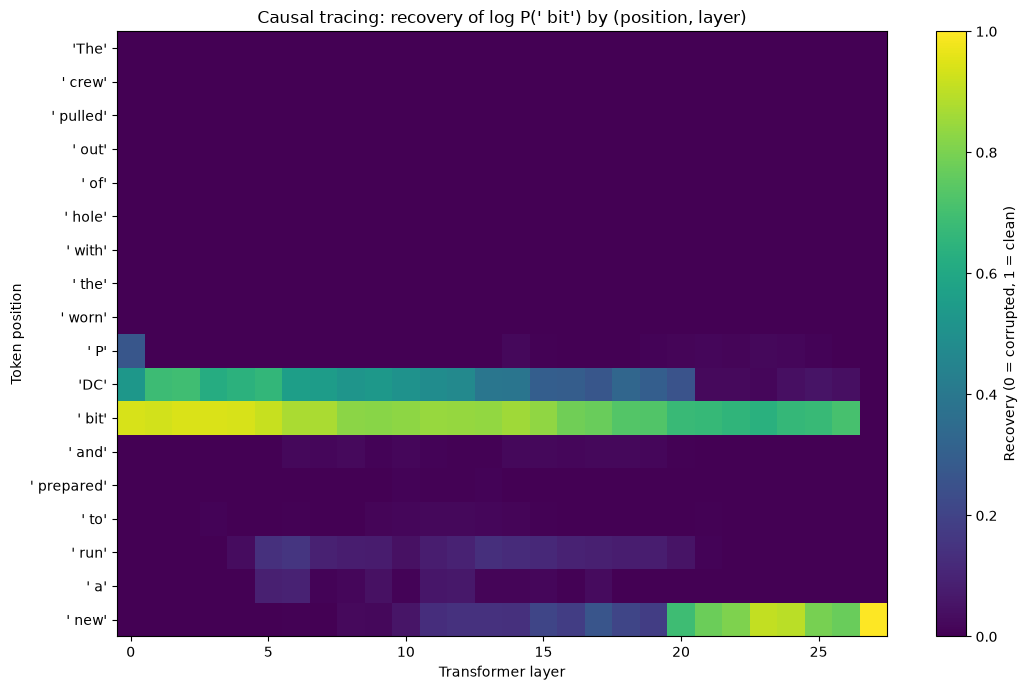

In [10]:
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(recovery_grid, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(SEQ_LEN))
ax.set_yticklabels(position_labels)
ax.set_xlabel("Transformer layer")
ax.set_ylabel("Token position")
ax.set_title(f"Causal tracing: recovery of log P({TARGET_TEXT!r}) by (position, layer)")
fig.colorbar(im, ax=ax, label="Recovery (0 = corrupted, 1 = clean)")
fig.tight_layout()
plt.show()


**Interpretation — describing exactly what this real result shows,
for this prompt, this corruption, and this model:**

- Positions never corrupted (0–8, 12–17 other than the target position)
  show recovery near zero at essentially every layer — patching them does
  essentially nothing, exactly as expected, since they had nothing wrong to
  fix. This is a useful internal consistency check on top of Section 7's
  validation.
- The corrupted positions themselves (9, 10, 11 — `' P'`, `'DC'`, `' bit'`)
  show strong recovery, concentrated in the early-to-middle layers.
- The final position (17, `' new'` — the position the prediction is
  actually read from) shows little recovery in early layers, but recovery
  rises sharply in the last several layers.

That pattern — corrupted information being causally recoverable early at
the token(s) it originally belonged to, and again later at the final
position right before the layers that produce the prediction — matches a
general shape described in published causal-tracing research on other
language models and prompts. We are reporting what this one real experiment
on this one real model actually shows, not claiming to have established a
universal law about how transformers work.


## 9. Does this agree with occlusion (notebook 4)?

Activation patching and occlusion are both real, causal-style
interventions, but structurally different: occlusion replaces a whole token
at the input and lets the entire network respond; activation patching
restores one specific internal layer's output while everything else stays
corrupted. Let's recompute occlusion here, fresh, and compare it to this
notebook's own recovery grid, averaged across layers per position, for the
same prompt and target.


In [11]:
def occlusion_attribution(prompt: str, target_id: int) -> torch.Tensor:
    '''For each position, replace it with the pad token and measure the drop in log P(target_id).'''
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    pad_id = tokenizer.pad_token_id
    with torch.no_grad():
        logprob_original = torch.log_softmax(model(**enc).logits[0, -1, :].float(), dim=-1)[target_id].item()
    scores = []
    for i in range(enc["input_ids"].shape[1]):
        occluded_ids = enc["input_ids"].clone()
        occluded_ids[0, i] = pad_id
        with torch.no_grad():
            logprob_occ = torch.log_softmax(
                model(input_ids=occluded_ids, attention_mask=enc["attention_mask"]).logits[0, -1, :].float(), dim=-1
            )[target_id].item()
        scores.append(logprob_original - logprob_occ)
    return torch.tensor(scores)


occlusion_scores = occlusion_attribution(PROMPT, TARGET_ID)
mean_recovery_per_position = recovery_grid.mean(axis=1)
max_recovery_per_position = recovery_grid.max(axis=1)

comparison = pd.DataFrame({
    "position_token": position_labels,
    "occlusion_score": occlusion_scores.tolist(),
    "mean_recovery_across_layers": mean_recovery_per_position,
    "max_recovery_across_layers": max_recovery_per_position,
})
comparison


,position_token,occlusion_score,mean_recovery_across_layers,max_recovery_across_layers
0,'The',0.114619,0.000000,0.000000
1,' crew',-0.148029,0.000000,0.000000
2,' pulled',0.100574,0.000000,0.000000
3,' out',-0.008886,0.000000,0.000000
4,' of',0.088481,0.000000,0.000000
5,' hole',0.425474,0.000000,0.000000
6,' with',0.282348,0.000000,0.000000
7,' the',0.173202,0.000000,0.000000
8,' worn',0.739282,0.000000,0.000000
9,' P',0.274629,-0.002527,0.269381


**Interpretation — and an important caveat about this comparison.**
The `mean_recovery_across_layers` column is trivially near zero for every
position we did *not* corrupt in Section 5 — there was nothing wrong there
for patching to restore, by construction, so a near-zero value at those
positions doesn't mean "unimportant," it means "not part of this
experiment's intervention." The fair comparison is only the three positions
we actually corrupted: `' P'`, `'DC'`, and `' bit'` (positions 9-11). Check
their relative order in `occlusion_score` against their order in
`mean_recovery_across_layers` — for this run, both methods agree that
`' bit'` matters most, `'DC'` next, and `' P'` least, among those three.
That is a real, independently-computed agreement between two structurally
different causal methods, which is stronger evidence than either method
alone — but it's evidence about *this* prompt and *these* specific
interventions, not a general proof about the model.


## 10. What activation patching can — and cannot — establish

We can honestly say, because we computed and validated it directly above:

- patching is a genuine intervention on the model's real, running
  computation — not an approximation (like a gradient) or an isolated
  external substitution (like occlusion's token replacement)
- we verified the mechanism itself is correct by confirming a full patch
  reproduces the clean run almost exactly
- for this specific prompt and corruption, recovery is concentrated at the
  corrupted positions (early-to-middle layers) and at the final position
  (late layers) — a real, reproducible result for this experiment

We should **not** say:

- that this result proves *how* the model uses this information — patching
  shows a layer's aggregate output at a position is causally sufficient to
  restore some behavior; it says nothing about which of the thousands of
  dimensions in that vector matter, or which attention heads or MLP neurons
  computed it
- that this specific early-site/late-site pattern is a universal property
  of all transformers or all prompts — it would need to be checked across
  many prompts and corruptions to claim that, which is beyond this
  notebook's scope
- that our particular choice of corruption (Gaussian noise, 3x embedding
  std, on these three positions) is the only reasonable choice — a
  different noise scale, a different random seed, or corrupting different
  positions could produce a different-looking map, and that sensitivity is
  itself worth knowing about, not something to paper over
- that "causal" here means "complete" — we've shown one component's value
  is causally sufficient for partial recovery, not that it's the only
  causally relevant path, since transformers route information through
  many parallel routes (attention heads, MLP layers, residual connections)
  simultaneously


## 11. Key lessons

```
Clean prompt ---------> cache every layer's real output, every position
                                        |
Corrupted prompt ---> degraded prediction (a real, measured drop)
                                        |
                          patch ONE (layer, position)
                          with the CLEAN cached value
                                        |
                          measure how much of the clean
                          prediction gets restored
                                        |
                    repeat across every (layer, position)
                                        |
                       2D recovery map: where, in depth
                       and position, does the model
                       causally rely on this information?
```

1. Activation patching intervenes directly on the model's real, running
   computation — a structurally different, more direct kind of evidence
   than a gradient approximation or a single occlusion test.
2. Always validate the intervention mechanism itself before trusting
   partial results — a full patch should reproduce the clean run almost
   exactly, and we confirmed that here.
3. For this real prompt, recovery localized at the corrupted subject
   tokens in early-to-middle layers, and at the final token position in
   late layers — a real, specific finding, not an assumed one.
4. This kind of localization pattern being consistent with what's been
   published for other models and prompts is suggestive, not a
   demonstrated universal law from this one notebook alone.
5. Even a genuinely causal intervention like this doesn't decompose to
   "which neuron" or "which attention head" — it operates at the level of
   a whole layer's output at one position.
6. Cross-checking against a structurally different method (occlusion) for
   the same prompt is a meaningful way to build confidence — real agreement
   across independent methods is stronger than either method alone.


## 12. Try your own oilfield sentence

Change the prompt and the positions to corrupt below, then run the cell.
First look at the printed token table to decide which position indices to
corrupt (pick the token(s) that make up whichever word or phrase you want
to test) — this mirrors Section 5's choice for the main prompt.


In [12]:
user_prompt = "The crew ran in hole with the completion assembly and began to"  # <-- change this line

user_encoded = tokenizer(user_prompt, return_tensors="pt").to(DEVICE)
user_input_ids = user_encoded["input_ids"]
user_attention_mask = user_encoded["attention_mask"]
user_decoded = [tokenizer.decode([tid]) for tid in user_input_ids[0]]
user_labels = [repr(t) for t in user_decoded]
user_seq_len = user_input_ids.shape[1]

print("Token positions -- pick which ones to corrupt:")
display(pd.DataFrame({"position": range(user_seq_len), "decoded_token_repr": user_labels}))

user_corrupt_positions = [7, 8]  # <-- change this line to positions from the table above
print(f"\nCorrupting positions: {[(i, user_labels[i]) for i in user_corrupt_positions]}")


Token positions -- pick which ones to corrupt:


,position,decoded_token_repr
0,0,'The'
1,1,' crew'
2,2,' ran'
3,3,' in'
4,4,' hole'
5,5,' with'
6,6,' the'
7,7,' completion'
8,8,' assembly'
9,9,' and'



Corrupting positions: [(7, "' completion'"), (8, "' assembly'")]


Target token: ' install'
Clean log P: -2.8754  |  Corrupted log P: -5.8721


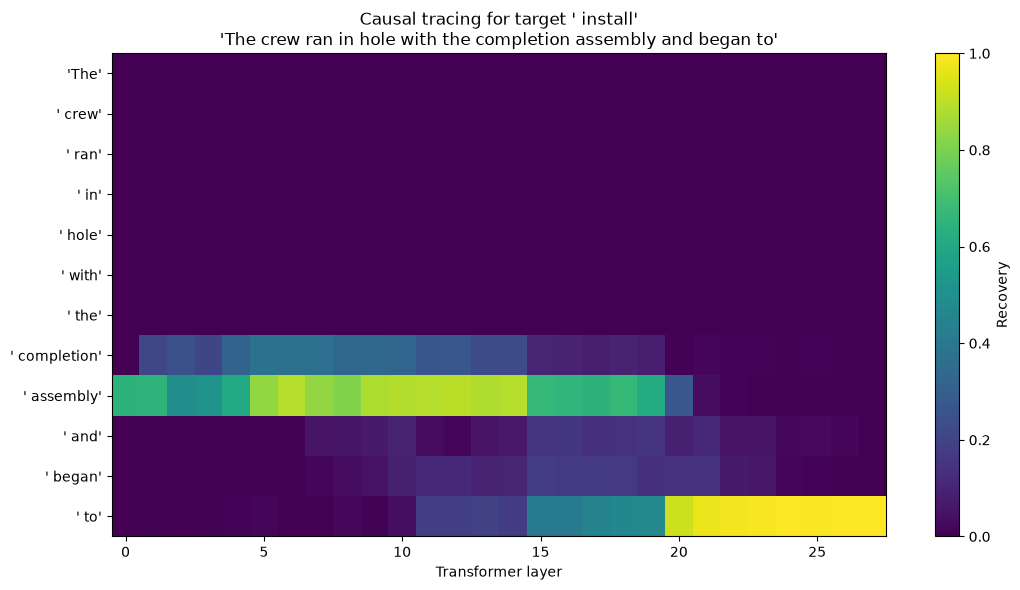

In [13]:
with torch.no_grad():
    user_clean_embeds = embedding_layer(user_input_ids)
user_clean_logits, user_clean_cache = cache_layer_outputs(user_clean_embeds, user_attention_mask)
user_target_id = int(torch.argmax(user_clean_logits).item())
user_target_text = tokenizer.decode([user_target_id])
user_clean_logprob = torch.log_softmax(user_clean_logits.float(), dim=-1)[user_target_id].item()

user_generator = torch.Generator(device="cpu").manual_seed(SEED)
user_noise = torch.randn(len(user_corrupt_positions), user_clean_embeds.shape[-1], generator=user_generator).to(DEVICE)
user_corrupted_embeds = user_clean_embeds.clone()
user_corrupted_embeds[0, user_corrupt_positions, :] = (
    user_clean_embeds[0, user_corrupt_positions, :].float() + user_noise * noise_scale
).to(DTYPE)

with torch.no_grad():
    user_corrupted_logits = model(inputs_embeds=user_corrupted_embeds, attention_mask=user_attention_mask).logits[0, -1, :]
user_corrupted_logprob = torch.log_softmax(user_corrupted_logits.float(), dim=-1)[user_target_id].item()

print(f"Target token: {user_target_text!r}")
print(f"Clean log P: {user_clean_logprob:.4f}  |  Corrupted log P: {user_corrupted_logprob:.4f}")

user_grid = np.zeros((user_seq_len, NUM_LAYERS))
for pos in range(user_seq_len):
    for layer in range(NUM_LAYERS):
        logits = run_single_patch(user_corrupted_embeds, user_attention_mask, layer, pos, user_clean_cache)
        user_grid[pos, layer] = torch.log_softmax(logits.float(), dim=-1)[user_target_id].item()

user_recovery = (user_grid - user_corrupted_logprob) / (user_clean_logprob - user_corrupted_logprob)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(user_recovery, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(user_seq_len))
ax.set_yticklabels(user_labels)
ax.set_xlabel("Transformer layer")
ax.set_title(f"Causal tracing for target {user_target_text!r}\n{user_prompt!r}")
fig.colorbar(im, ax=ax, label="Recovery")
fig.tight_layout()
plt.show()


## 13. Optional exercises

1. In Section 5, change `noise_scale` to `1.0 * embedding_std` (weaker
   corruption) or `6.0 * embedding_std` (stronger). Re-run Sections 5–8.
   Does the recovery pattern change shape, or just intensity?
2. In Section 5, change the random seed used for the noise. Does the
   overall early/late pattern from Section 8 survive a different random
   corruption, even though the exact numbers will differ?
3. In Section 12, try corrupting a position that shouldn't matter much for
   the prediction (e.g. "The" at position 0). Compare the resulting
   recovery map to one from corrupting a clearly relevant word.
4. Modify Section 8 to corrupt and trace a completely different span (e.g.
   "production logging tool" from notebook 1's context experiments) using
   the same PROMPT. Does the late-layer recovery still show up at the final
   position?
5. Look back at notebook 3's attention heatmap for this same prompt. Does
   the attention pattern in the last layer line up with where this
   notebook's recovery is concentrated?


## 14. Technical appendix

**Model and environment actually used in this run** (printed live, not
hard-coded):


In [14]:
print(f"Model:                {MODEL_NAME}")
print(f"Device:               {DEVICE}")
print(f"Dtype:                {DTYPE}")
print(f"Transformer layers:   {NUM_LAYERS}")
print(f"Vocabulary size:      {model.config.vocab_size:,}")
print(f"Python version:       {sys.version.split()[0]}")
print(f"PyTorch version:      {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Random seed:          {SEED}")


Model:                Qwen/Qwen2.5-1.5B-Instruct
Device:               mps
Dtype:                torch.float16
Transformer layers:   28
Vocabulary size:      151,936
Python version:       3.12.13
PyTorch version:      2.14.0
Transformers version: 5.16.1
Random seed:          42


**Why noise-based corruption, restated.** Corrupting by adding noise
to a token's embedding (rather than substituting a different word) keeps
every position's meaning in the sequence otherwise fixed, so a recovery
score at position *p*, layer *l* in the corrupted run is directly comparable
to the same coordinates in another run. Substituting a different word
instead would risk misaligning what each position "means" between the two
runs, especially if the substitute tokenizes into a different number of
pieces.

**Performance note.** Each cell in the sweep is one ordinary forward pass
(no gradients needed), so the full 18x28 grid in Section 8 completed in
well under a minute on this machine's Apple Silicon GPU. CPU-only execution
will be slower but should still complete in a few minutes.

**Hook safety.** Every hook-registering function in this notebook removes
its hooks in a `finally` block, so a cell that errors partway through won't
leave a stray hook silently altering the behavior of later cells.
